# PCA bases - statistics
03.27.2026

How do each of these basis compare? RMS, self response, etc. 

Interested in comparing how the amplitude and sparkle angle impact these values.

Also contributes to knowing which claibrations have a flat as the dominant mode. 

In [97]:
# function to go through each basis, calculate the RMS, self RMS, and ratio of self RMS to RMS
calib_dir = "/home/eden/data/spark_calib"
import sparkles.calibration_iter as calibi 
from importlib import reload
from astropy.io import fits

In [107]:
reload(calibi)

df_all = calibi.calibration_rms_df("/home/eden/data/spark_calib")

/tmp/ipykernel_1580841/2145112482.py:3: UserWarning: Skipping sep22_ang60_amp0.030_freq2000: missing ref_rms.fits
  df_all = calibi.calibration_rms_df("/home/eden/data/spark_calib")


In [108]:
df = df_all[df_all["spark_amp"] <= 0.04].sort_values("spark_amp", ascending=False)


In [109]:
# For a given sparkle separation, plot angle/amplitude impact on RMS.
# One heatmap per PCA mode.

import numpy as np
import matplotlib.pyplot as plt


def plot_rms_by_mode_grid(df, spark_sep, value_col="rms", cmap="viridis"):
    sub = df[df["spark_sep"] == spark_sep].copy()
    if sub.empty:
        raise ValueError(f"No rows found for spark_sep={spark_sep}")

    modes = sorted(sub["pca_mode"].unique())
    n_modes = len(modes)
    n_cols = min(3, n_modes)
    n_rows = int(np.ceil(n_modes / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.8 * n_cols, 4.0 * n_rows),
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    vmin = sub[value_col].min()
    vmax = sub[value_col].max()

    for i, mode in enumerate(modes):
        ax = axes[i]
        mode_df = sub[sub["pca_mode"] == mode]
        grid = mode_df.pivot_table(
            index="spark_ang", columns="spark_amp", values=value_col, aggfunc="mean"
        ).sort_index(axis=0).sort_index(axis=1)

        im = ax.imshow(
            grid.values,
            aspect="auto",
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(f"PCA mode {mode}")
        ax.set_xlabel("spark_amp")
        ax.set_ylabel("spark_ang")
        ax.set_xticks(np.arange(len(grid.columns)))
        ax.set_xticklabels([f"{x:.3f}" for x in grid.columns], rotation=45, ha="right")
        ax.set_yticks(np.arange(len(grid.index)))
        ax.set_yticklabels([f"{y:.0f}" for y in grid.index])

    for j in range(n_modes, len(axes)):
        axes[j].axis("off")

    cbar = fig.colorbar(im, ax=axes[:n_modes], shrink=0.95)
    cbar.set_label(value_col)
    fig.suptitle(f"Separation {spark_sep}: {value_col} by angle/amplitude", y=1.02)
    return fig, axes


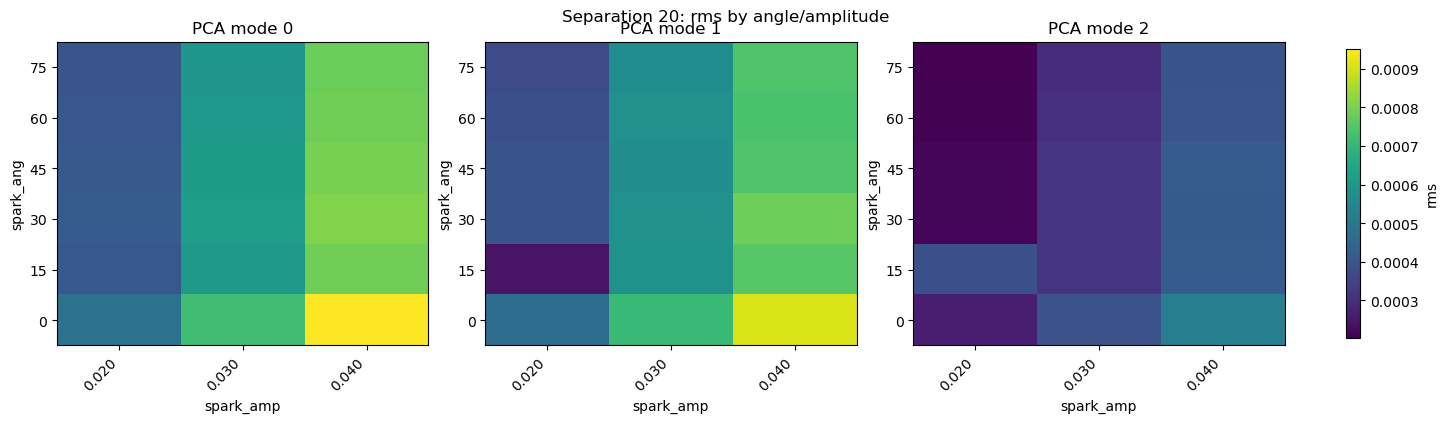

In [131]:
# separation 18 
plot_rms_by_mode_grid(df, spark_sep=20, value_col="rms")
plt.show()

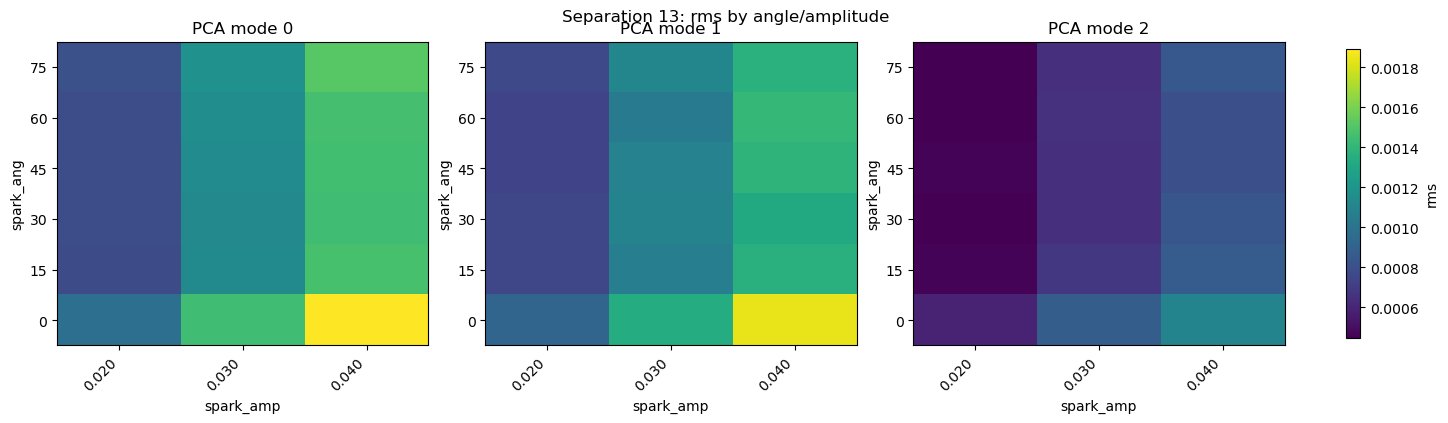

In [138]:
plot_rms_by_mode_grid(df, spark_sep=13, value_col="rms")
plt.show()

## PCA RMS line plots by mode (angle = 0)

Separation on x-axis, `pca_rms` on y-axis, filtered to `spark_ang == 0`.
- Line style encodes `spark_amp`
- One subplot per `pca_mode`

In [126]:
from matplotlib.lines import Line2D


def plot_pca_rms_by_mode_lines(
    df,
    angle_value=0.0,
    x_col="spark_sep",
    y_col="pca_rms",
    sep_col="spark_sep",
    amp_col="spark_amp",
    ang_col="spark_ang",
    mode_col="pca_mode",
):
    # Deduplicate selected columns in case x_col and sep_col are the same.
    cols = list(dict.fromkeys([x_col, y_col, sep_col, amp_col, ang_col, mode_col]))
    sub = df[cols].dropna().copy()
    sub = sub[np.isclose(sub[ang_col], angle_value)]
    if sub.empty:
        raise ValueError(f"No rows found for {ang_col} == {angle_value}.")

    modes = sorted(sub[mode_col].unique())
    amps = sorted(sub[amp_col].unique())

    n_modes = len(modes)
    n_cols = min(3, n_modes)
    n_rows = int(np.ceil(n_modes / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.0 * n_cols, 3.8 * n_rows),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    style_cycle = ["-", "--", "-.", ":"]
    amp_to_style = {amp: style_cycle[i % len(style_cycle)] for i, amp in enumerate(amps)}
    amp_cmap = plt.get_cmap("tab10")
    amp_to_color = {amp: amp_cmap(i % amp_cmap.N) for i, amp in enumerate(amps)}

    for i, mode in enumerate(modes):
        ax = axes[i]
        mode_df = sub[sub[mode_col] == mode]

        for amp in amps:
            line_df = mode_df[mode_df[amp_col] == amp]
            if line_df.empty:
                continue
            line_df = line_df.sort_values(x_col)
            ax.plot(
                line_df[x_col],
                line_df[y_col],
                color=amp_to_color[amp],
                linestyle=amp_to_style[amp],
                marker="o",
                linewidth=1.8,
                markersize=3.8,
                alpha=0.95,
                label=f"amp {amp:.3f}",
            )

        ax.set_title(f"PCA mode {mode}")
        ax.set_xlabel("spark_sep")
        ax.set_ylabel(y_col)
        ax.grid(alpha=0.25)

    for j in range(n_modes, len(axes)):
        axes[j].axis("off")

    amp_handles = [
        Line2D(
            [0],
            [0],
            color=amp_to_color[amp],
            linestyle=amp_to_style[amp],
            lw=2,
            label=f"amp {amp:.3f}",
        )
        for amp in amps
    ]
    axes[0].legend(handles=amp_handles, title="Amplitude", loc="best", fontsize=8)

    fig.suptitle(
        f"PCA RMS vs separation by mode (spark_ang = {angle_value:.0f})",
        y=1.02,
    )
    return fig, axes

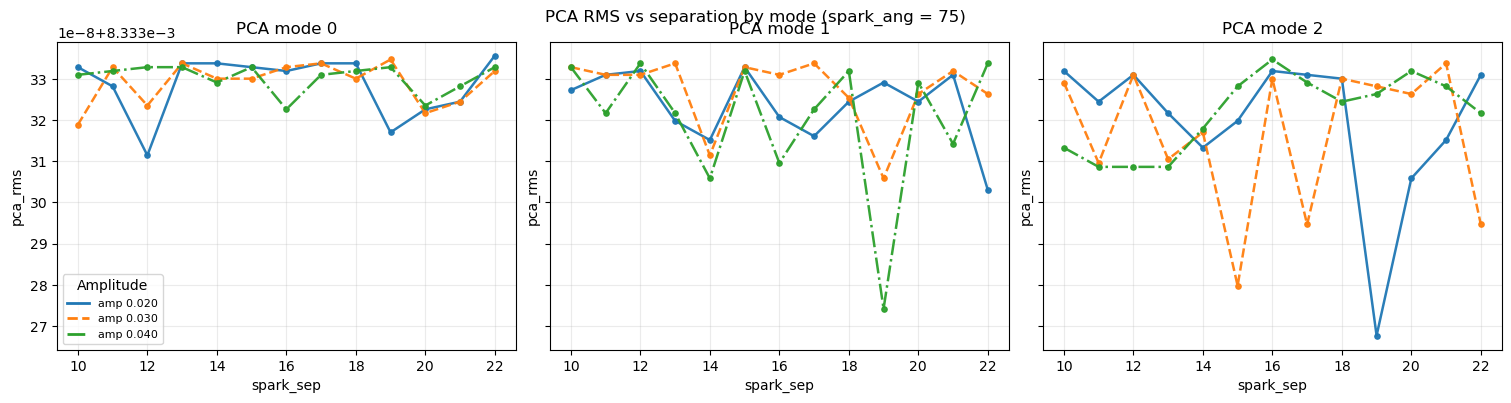

In [130]:
plot_pca_rms_by_mode_lines(df, angle_value=75)
plt.show()

### check all together

### check a particular calib

In [117]:
# looking at an example of a pca mode 14 15 0.03
sub = df[df["spark_sep"] == 18]
sub = sub[sub["spark_ang"] == 15]
sub = sub[sub["spark_amp"] == 0.03]
sub['calib_path'].reset_index(drop=True)[0]

'/home/eden/data/spark_calib/sep18_ang15_amp0.030_freq2000'

In [115]:
# check out what the pca image looks like 
test_path = sub['calib_path'].reset_index(drop=True)[0]
fits_f = test_path + "/ref_pca.fits"
fits_data = fits.open(fits_f)[0].data.T
pca_img = fits_data.reshape(3,120,120)

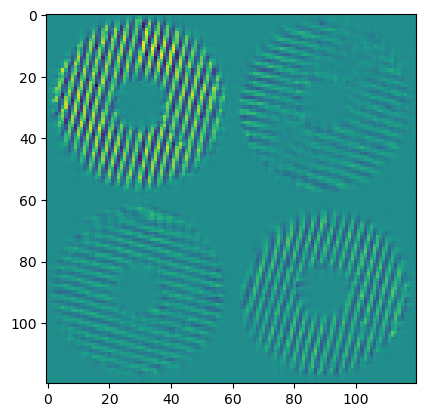

In [116]:
plt.imshow(pca_img[2])

## Testing a faster method of PCA for re-calculating

In [78]:
import sklearn
import calibrator.spark_calib as sc
import sparkles.pca as pca
reload(pca)


<module 'sparkles.pca' from '/home/eden/code/sparkles/src/sparkles/pca.py'>

In [67]:
# load in a calibration object for the purposes of pulling the data. 
calibration_folder = "/home/eden/data/spark_calib"
sep = 18
ang = 45
amp = 0.030
freq_used = 2000

cspk = sc.SparkCalib()
cspk.setup(calibration_folder, sep, ang, amp, freq_used)

Path exists: /home/eden/data/spark_calib/sep18_ang45_amp0.030_freq2000


True

In [68]:
# now we want it to look for and pull the data 
cspk.read_savedata()
data = cspk.grab_cube()

Found 322 files in the folder /opt/MagAOX/rawimages/aol1_imWFS2/2026_03_18
Found 3 files between aol1_imWFS2_20260318150320689150000.xrif and aol1_imWFS2_20260318150322951164000.xrif


In [95]:
cspk.gen_lab_ref(data, n_pca=4000, klip=5, iter_rms=False)

GENERATING REFERENCE PCA basis
Using 4000 frames out of 4526


(array([[ 1.68624528e-04, -3.26660884e-05, -1.28983718e-04,
          1.15518256e-04, -4.65254409e-05],
        [-5.14678715e-05, -5.47940084e-05, -2.35975114e-04,
         -1.35143059e-04,  4.84009638e-04],
        [ 1.22263404e-04, -1.92703787e-04, -4.31247765e-05,
         -1.05031436e-04,  4.88487167e-05],
        ...,
        [ 6.19672951e-05, -2.42480331e-04, -7.08397148e-05,
         -1.74221296e-04, -6.57854970e-05],
        [-6.57711139e-06, -1.45929082e-04, -1.99819137e-04,
         -1.32406335e-04,  3.67574146e-04],
        [ 1.26665508e-04, -1.82011866e-06, -1.15882935e-04,
          9.35883947e-05, -4.96177939e-05]], shape=(14400, 5)),
 array([[[ 1.68624528e-04, -5.14678715e-05,  1.22263404e-04, ...,
           9.34561585e-05, -4.23527764e-05,  8.91831872e-05],
         [ 2.14959802e-05,  2.58406213e-04,  1.04524480e-05, ...,
           2.09912383e-05,  3.09719257e-04,  3.06765099e-05],
         [ 9.82529570e-05, -1.70620311e-05, -4.20431132e-06, ...,
          -5.80303603

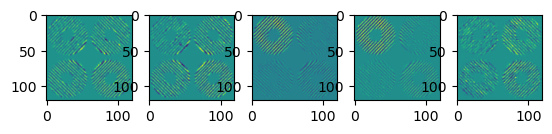

In [96]:
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(cspk.ref_pca_img[i])
plt.show()

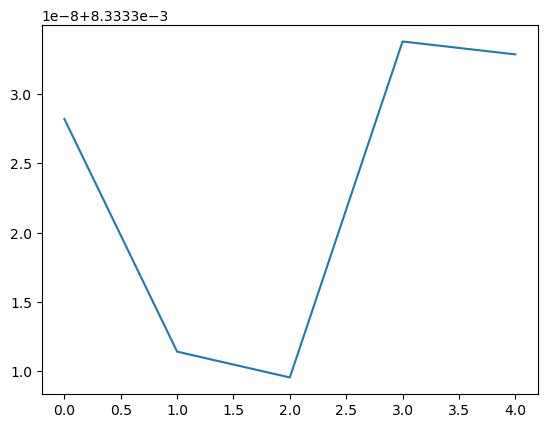

In [90]:
plt.plot(np.std(solvr.components_, axis=1))
plt.show()


## PCA RMS by mode for two angles

Compare exactly two angles:
- color encodes angle
- line style encodes amplitude
- x-axis is separation (`spark_sep`)
- y-axis is `pca_rms`
- one subplot per PCA mode

In [ ]:
from matplotlib.lines import Line2D


def plot_pca_rms_by_mode_two_angles(
    df,
    angles=(0.0, 75.0),
    x_col="spark_sep",
    y_col="pca_rms",
    ang_col="spark_ang",
    amp_col="spark_amp",
    mode_col="pca_mode",
):
    if len(angles) != 2:
        raise ValueError("angles must contain exactly two values.")

    angle_vals = [float(angles[0]), float(angles[1])]
    cols = list(dict.fromkeys([x_col, y_col, ang_col, amp_col, mode_col]))
    sub = df[cols].dropna().copy()
    sub = sub[sub[ang_col].isin(angle_vals)]
    if sub.empty:
        raise ValueError(f"No rows found for angles={angle_vals}.")

    modes = sorted(sub[mode_col].unique())
    amps = sorted(sub[amp_col].unique())

    n_modes = len(modes)
    n_cols = min(3, n_modes)
    n_rows = int(np.ceil(n_modes / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.2 * n_cols, 3.9 * n_rows),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    # Color by angle, style by amplitude.
    angle_to_color = {angle_vals[0]: "tab:blue", angle_vals[1]: "tab:orange"}
    style_cycle = ["-", "--", "-.", ":"]
    amp_to_style = {amp: style_cycle[i % len(style_cycle)] for i, amp in enumerate(amps)}

    for i, mode in enumerate(modes):
        ax = axes[i]
        mode_df = sub[sub[mode_col] == mode]

        for angle in angle_vals:
            for amp in amps:
                line_df = mode_df[
                    np.isclose(mode_df[ang_col], angle) & (mode_df[amp_col] == amp)
                ]
                if line_df.empty:
                    continue
                line_df = line_df.sort_values(x_col)
                ax.plot(
                    line_df[x_col],
                    line_df[y_col],
                    color=angle_to_color[angle],
                    linestyle=amp_to_style[amp],
                    marker="o",
                    linewidth=1.8,
                    markersize=3.8,
                    alpha=0.95,
                )

        ax.set_title(f"PCA mode {mode}")
        ax.set_xlabel("spark_sep")
        ax.set_ylabel(y_col)
        ax.grid(alpha=0.25)

    for j in range(n_modes, len(axes)):
        axes[j].axis("off")

    angle_handles = [
        Line2D([0], [0], color=angle_to_color[a], lw=2, label=f"ang {a:.0f}")
        for a in angle_vals
    ]
    amp_handles = [
        Line2D([0], [0], color="black", linestyle=amp_to_style[amp], lw=2, label=f"amp {amp:.3f}")
        for amp in amps
    ]

    leg1 = axes[0].legend(handles=angle_handles, title="Angle", loc="lower left", fontsize=8)
    axes[0].add_artist(leg1)
    axes[0].legend(handles=amp_handles, title="Amplitude", loc="lower right", fontsize=8)

    fig.suptitle(
        f"PCA RMS vs separation by mode (angles: {angle_vals[0]:.0f}, {angle_vals[1]:.0f})",
        y=1.02,
    )
    return fig, axes